# Dialogue and Sentiment Analysis in Shakespeare's Hamlet
**Data Analytics with R — Group 3**

This notebook walks through the full analysis pipeline used to produce the team's final visualisation poster. It produces three plots:

1. A **Gantt-style speaking timeline** showing when the top 6 characters speak across the play
2. A **cumulative sentiment progression** tracking Hamlet's emotional arc line-by-line
3. A **chord diagram** of character co-occurrences by scene

All three are assembled into a single poster layout and exported as a PDF.

---

## 1. Environment Setup

`renv` creates a **project-local, reproducible R library**. Running `renv::init()` locks all package versions so the analysis produces identical results on any machine.

> Only run this cell once per machine. Skip it if `renv` is already initialised.

In [808]:
install.packages("renv")
renv::init()        # initializes the project-local library

# Install packages required for the bonus visualisations (Sections 20–21)
# that may not yet be in the renv lockfile
bonus_pkgs <- c("tidygraph", "ggraph", "igraph", "SnowballC")
missing    <- bonus_pkgs[!sapply(bonus_pkgs, requireNamespace, quietly = TRUE)]
if (length(missing) > 0) install.packages(missing)

The following package(s) will be installed:
- renv [1.1.8]
These packages will be installed into "~/R_Hamlet_DataVizClub/renv/library/windows/R-4.5/x86_64-w64-mingw32".

# Installing packages --------------------------------------------------------
- Installing renv 1.1.8 ...                     OK [linked from cache]
- The project is out-of-sync -- use `renv::status()` for details.


## 2. Load Libraries

| Package | Purpose |
|---|---|
| `tidyverse` | Data wrangling and ggplot2 plotting (includes `ggplot2`) |
| `tidytext` | Text tokenisation and stop-word removal |
| `widyr` | Pairwise co-occurrence counting between characters |
| `circlize` | Chord diagrams (base R graphics) |
| `patchwork` | Composing multiple plots into one layout |
| `grid` | Low-level graphics — `rasterGrob`, `textGrob`, `gpar`, `unit` |
| `png` | Reading PNG files back into R |
| `cowplot` | `ggdraw` and `draw_grob` for the summary text panel |
| `showtext` | Loading Google Fonts via `font_add_google` / `showtext_auto` |
| `tidygraph` | Tidy graph manipulation — wraps `igraph` as a tibble-friendly API |
| `ggraph` | Graph/network visualisation built on top of ggplot2 |
| `igraph` | Graph layout algorithms (used internally by `ggraph`) |
| `SnowballC` | Word stemming — reduces words to their root form (e.g. "running" → "run") |

In [809]:
library(tidyverse)   # Data manipulation and plotting
library(tidytext)    # Text tokenisation and stop-word removal
library(widyr)       # Pairwise co-occurrence counting
library(patchwork)   # Compose multiple plots into one layout
library(grid)        # rasterGrob, textGrob, gpar, unit
library(gridExtra)   # tableGrob for the Lion King comparison table
library(png)         # readPNG
library(cowplot)     # ggdraw, draw_grob
library(showtext)    # Google Fonts
library(tidygraph)   # Tidy graph/network manipulation
library(ggraph)      # Network visualisation
library(igraph)      # Graph layout algorithms
library(SnowballC)   # Word stemming

## 3. Load the Hamlet Dataset

The dataset is stored as an `.RData` file. Each row is one line of dialogue with columns for `character`, `act`, `scene`, `line_number`, and `dialogue`.

`view()` opens an interactive table in RStudio — replace with `print()` or `head()` if running non-interactively.

In [810]:
load('01_hamlet.RData')
head(hamlet)

act,scene,character,dialogue,line_number
<chr>,<chr>,<chr>,<chr>,<dbl>
Act I,Scene I,[stage direction],FRANCISCO at his post. Enter to him BERNARDO,NA
Act I,Scene I,Bernardo,Who's there?,1
Act I,Scene I,Francisco,"Nay, answer me: stand, and unfold yourself.",2
Act I,Scene I,Bernardo,Long live the king!,3
Act I,Scene I,Francisco,Bernardo?,4
Act I,Scene I,Bernardo,He.,5


## 4. Identify the Top 8 Characters by Dialogue Volume

Stage directions are excluded. Characters are ranked by number of spoken lines and the top 8 are selected. These eight characters appear consistently across all visualisations.

In [811]:
top_characters <- hamlet %>%
  filter(character != "[stage direction]") %>%
  count(character, sort = TRUE) %>%
  slice_max(n, n = 8)

main_characters <- top_characters$character
print(main_characters)

[1] "Hamlet"         "King Claudius"  "Lord Polonius"  "Horatio"       
[5] "Laertes"        "Ophelia"        "Queen Gertrude" "Ghost"         


## 5. Define a Consistent Color Palette

A named color vector ensures each character is represented by the **same color across all three plots**. Colors are drawn from a vintage theatrical palette to evoke the period of the play:

- **Hamlet** — Deep Crimson Red `#7e1215`, tragic passion and blood
- **King Claudius** — Deep Sapphire Blue `#1a2b4b`, cold royal ambition
- **Lord Polonius** — Old Ochre Gold `#a07a3c`, pompous and aged courtly wisdom
- **Horatio** — Jewel Teal-Green `#1f5c53`, steady loyalty
- **Laertes** — Burnished Gold-Orange `#d48b1d`, impulsive fiery energy
- **Ophelia** — Soft Grey-Blue `#a8bcc6`, delicate melancholy and her watery end
- **Queen Gertrude** — Rich Garnet Purple-Red `#5e2129`, regal yet ensnared
- **Rosencrantz** — Warm Grey-Putty `#7a7065`, an unremarkable minor courtier
- **Ghost** — Deep Shadow Blue-Green `#10302b`, supernatural darkness from the underworld

In [812]:
character_colors <- c(
  "Hamlet"         = "#7e1215",   # Deep Crimson Red        — tragic passion and blood
  "King Claudius"  = "#1a2b4b",   # Deep Sapphire Blue      — cold royal ambition
  "Lord Polonius"  = "#a07a3c",   # Old Ochre Gold          — pompous, aged courtly wisdom
  "Horatio"        = "#1f5c53",   # Jewel Teal-Green        — steady loyalty
  "Laertes"        = "#d48b1d",   # Burnished Gold-Orange   — impulsive, fiery energy
  "Ophelia"        = "#a8bcc6",   # Soft Grey-Blue          — delicate melancholy, watery end
  "Queen Gertrude" = "#5e2129",   # Rich Garnet Purple-Red  — regal yet ensnared
  "Rosencrantz"    = "#7a7065",   # Warm Grey-Putty         — unremarkable minor courtier
  "Ghost"          = "#10302b"    # Deep Shadow Blue-Green  — supernatural, dark, otherworldly
)

## 6. Load Fonts

Three Google Fonts are loaded via `showtext`:
- **EB Garamond** — elegant serif for body text and axis labels
- **MedievalSharp** — display font for section headers
- **UnifrakturMaguntia** — blackletter font for the poster title

`showtext_auto()` tells ggplot2 to use these fonts automatically in all subsequent plots.

In [813]:
# Load Google Fonts for all plots
font_add_google("EB Garamond", "Garamond")
font_add_google("MedievalSharp", "MedievalSharp")
font_add_google("UnifrakturMaguntia", "UnifrakturMaguntia")
showtext_auto()

## 7. Compute Total Lines per Character

Total lines spoken by each of the top 6 characters are counted and stored as a **factor ordered from fewest to most lines** (reversed). This ordering controls the y-axis direction in the Gantt chart, placing the highest-speaking character at the top.

In [814]:
character_totals <- hamlet %>%
  filter(character %in% main_characters) %>%
  count(character, name = "total_lines") %>%
  arrange(desc(total_lines))

# Store as a factor in reversed order so the most-speaking character plots at the top
character_totals <- character_totals %>%
  mutate(character = factor(character, levels = rev(character_totals$character)))

print(character_totals)

# A tibble: 8 × 2
  character      total_lines
  <fct>                <int>
1 Hamlet                1495
2 King Claudius          546
3 Lord Polonius          355
4 Horatio                289
5 Laertes                206
6 Ophelia                173
7 Queen Gertrude         157
8 Ghost                   95


## 9. Calculate Act Boundaries

The minimum and maximum `line_number` within each act give us the **start and end positions** for the vertical dividers. The midpoint is used to centre the act labels on the x-axis.

In [815]:
act_boundaries <- hamlet %>%
  group_by(act) %>%
  summarise(
    start_line = min(line_number, na.rm = TRUE),
    end_line   = max(line_number, na.rm = TRUE),
    .groups    = "drop"
  ) %>%
  mutate(mid_line = (start_line + end_line) / 2)

print(act_boundaries)

# A tibble: 5 × 4
  act     start_line end_line mid_line
  <chr>        <dbl>    <dbl>    <dbl>
1 Act I            1      913     457 
2 Act II         914     1660    1287 
3 Act III       1661     2588    2124.
4 Act IV        2589     3280    2934.
5 Act V         3281     4011    3646 


## 10. Define the Custom ggplot2 Theme

`hamlet_theme()` is a reusable function applied to every ggplot. Key design choices:

- **Base font**: EB Garamond at size 16 — readable and literary
- **Axis text size 20** — large enough to survive scaling down in the final poster
- **Alice blue background** (`#F0F8FF`) — soft and period-appropriate
- Minor grid lines are hidden to reduce visual clutter
- Legend is pinned to the bottom to avoid competing with the plot area

In [816]:
hamlet_theme <- function() {
  theme_minimal(base_family = "Garamond", base_size = 16) +
    theme(
      plot.title    = element_text(size = 26, face = "bold", margin = margin(b = 15), color = "black"),
      plot.subtitle = element_text(size = 16, hjust = 0.5, margin = margin(b = 20), color = "black"),

      axis.title = element_text(size = 22, face = "bold", color = "black"),
      axis.text  = element_text(size = 20, color = "black"),

      panel.grid.major  = element_line(color = "gray90", size = 0.3),
      panel.grid.minor  = element_blank(),

      strip.text = element_text(size = 16, face = "bold", color = "black"),

      plot.background   = element_rect(fill = "#F5E6C8", color = NA),
      panel.background  = element_rect(fill = "#F5E6C8", color = NA),
      legend.background = element_rect(fill = "#F5E6C8", color = NA),

      legend.position = "bottom",
      plot.margin     = margin(20, 20, 20, 20)
    )
}

## 10. Calculate Cumulative Sentiment — Hamlet & King Claudius

Each word is scored `+1` (positive) or `−1` (negative) via the Bing lexicon, then summed per line. `cumsum()` accumulates these scores chronologically for both Hamlet and King Claudius separately, producing two running totals that reveal each character's emotional trajectory through the play.

In [817]:
# Hamlet cumulative sentiment
hamlet_sentiment_by_line <- hamlet %>%
  filter(character == "Hamlet") %>%
  unnest_tokens(word, dialogue) %>%
  mutate(word = tolower(word)) %>%
  anti_join(stop_words, by = "word") %>%
  inner_join(get_sentiments("bing"), by = "word") %>%
  mutate(sentiment_value = ifelse(sentiment == "positive", 1, -1)) %>%
  group_by(line_number, act, scene) %>%
  summarize(
    line_sentiment = sum(sentiment_value),
    positive_words = sum(sentiment == "positive"),
    negative_words = sum(sentiment == "negative"),
    .groups = "drop"
  )

cumulative_hamlet <- hamlet_sentiment_by_line %>%
  arrange(line_number) %>%
  mutate(cumulative_sentiment = cumsum(line_sentiment),
         character = "Hamlet")

# King Claudius cumulative sentiment
cumulative_claudius <- hamlet %>%
  filter(character == "King Claudius") %>%
  unnest_tokens(word, dialogue) %>%
  mutate(word = tolower(word)) %>%
  anti_join(stop_words, by = "word") %>%
  inner_join(get_sentiments("bing"), by = "word") %>%
  mutate(sentiment_value = ifelse(sentiment == "positive", 1, -1)) %>%
  group_by(line_number, act, scene) %>%
  summarize(line_sentiment = sum(sentiment_value), .groups = "drop") %>%
  arrange(line_number) %>%
  mutate(cumulative_sentiment = cumsum(line_sentiment),
         character = "King Claudius")

# Combine both characters
cumulative_sentiment_by_line <- bind_rows(cumulative_hamlet, cumulative_claudius)

# Refresh act midpoints for label placement
act_boundaries <- act_boundaries %>%
  mutate(mid_line = (start_line + end_line) / 2)

## 11. Plot — Hamlet vs King Claudius Sentiment Progression

Two lines track the running sentiment totals for Hamlet (crimson) and King Claudius (sapphire). Dashed lines mark act boundaries; dotted lines mark three key dramatic events — Polonius's death, Ophelia's drowning, and the final bloodbath. Inline labels sit at the end of each line.

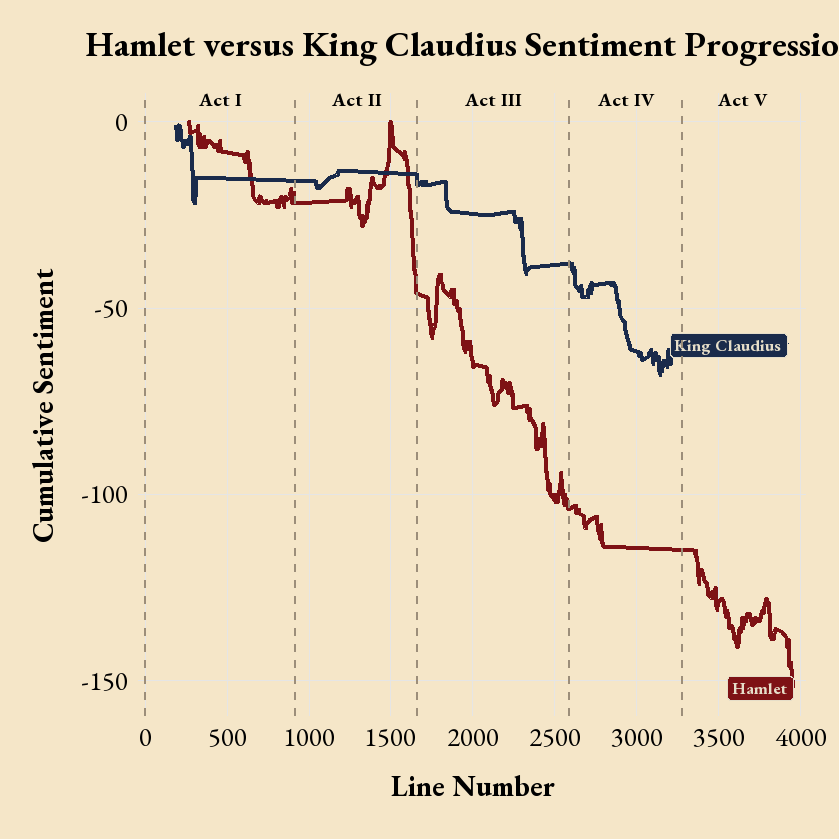

In [818]:
sentiment_char_colors <- c("Hamlet" = "#7e1215", "King Claudius" = "#1a2b4b")

# End-of-line label positions for each character
char_line_labels <- cumulative_sentiment_by_line %>%
  group_by(character) %>%
  slice_max(line_number, n = 1) %>%
  ungroup()

# ── Key dramatic events ─────────────────────────────────────────────────────
key_events <- hamlet %>%
  mutate(scene_int = suppressWarnings(as.integer(as.character(scene)))) %>%
  group_by(act, scene_int) %>%
  summarise(mid_line = mean(line_number, na.rm = TRUE), .groups = "drop") %>%
  filter(
    (act == "Act III" & scene_int == 4) |   # Polonius killed by Hamlet
    (act == "Act IV"  & scene_int == 7) |   # Ophelia's death reported
    (act == "Act V"   & scene_int == 2)     # Final bloodbath
  ) %>%
  mutate(event_label = case_when(
    act == "Act III" ~ "Polonius killed",
    act == "Act IV"  ~ "Ophelia drowns",
    TRUE             ~ "Final bloodbath"
  ))

# ── Plot ────────────────────────────────────────────────────────────────────
line_sentiment_plot <- cumulative_sentiment_by_line %>%
  ggplot(aes(x = line_number, y = cumulative_sentiment, color = character)) +
  geom_line(linewidth = 1.3) +
  # Key event vertical markers
  geom_vline(
    data        = key_events,
    aes(xintercept = mid_line),
    color       = "#5a110a",
    linetype    = "dotted",
    linewidth   = 0.9,
    inherit.aes = FALSE
  ) +
  # Key event labels (rotated, italic)
  geom_text(
    data        = key_events,
    aes(x = mid_line, label = event_label),
    y           = -5,
    angle       = 90,
    hjust       = 1,
    vjust       = -0.4,
    size        = 3.5,
    family      = "Garamond",
    fontface    = "italic",
    color       = "#5a110a",
    inherit.aes = FALSE
  ) +
  # Inline character labels at end of each line
  geom_label(
    data      = char_line_labels,
    aes(label = character, fill = character),
    color     = "#e6dec9",
    fontface  = "bold",
    family    = "Garamond",
    size      = 4.5,
    hjust     = 1,
    show.legend = FALSE
  ) +
  geom_vline(
    data = act_boundaries,
    aes(xintercept = start_line),
    color = "#9c8e7a", linetype = "dashed", linewidth = 0.8
  ) +
  geom_text(
    data        = act_boundaries,
    aes(x = mid_line, label = paste(act)),
    y           = Inf,
    vjust       = 1,
    family      = "Garamond",
    size        = 5,
    fontface    = "bold",
    color       = "black",
    inherit.aes = FALSE
  ) +
  scale_color_manual(values = sentiment_char_colors, guide = "none") +
  scale_fill_manual(values  = sentiment_char_colors, guide = "none") +
  scale_x_continuous(
    breaks = seq(0, 4000, 500),
    limits = c(0, 4000),
    expand = c(0.01, 0.01)
  ) +
  labs(
    title = "Hamlet versus King Claudius Sentiment Progression",
    x     = "Line Number",
    y     = "Cumulative Sentiment"
  ) +
  hamlet_theme() +
  theme(
    legend.position = "none",
    axis.text       = element_text(family = "Garamond"),
    axis.title.x    = element_text(margin = margin(t = 10), size = 22, face = "bold", family = "Garamond"),
    plot.title      = element_text(hjust = 0.5, family = "Garamond")
  )

print(line_sentiment_plot)

## 20. Bonus — Who Interacts With Whom? (Network Graph)

A play is essentially a series of **speaker hand-offs**: one character finishes speaking and another takes over. By counting how often each pair of characters hands off to one another (regardless of direction), we can build a network that shows the social structure of the play.

- **Node size** — total words spoken by that character across the full play
- **Edge colour / width** — number of times these two characters exchange turns
- The Kamada–Kawai (`kk`) layout places frequently-interacting characters spatially closer together

> **Key observation**: Hamlet sits at the centre with the heaviest connections, confirming his role as the dramatic hub. The Horatio–Hamlet edge is the strongest — matching their loyal relationship. Female characters (Ophelia, Gertrude) are visibly more peripheral, underscoring the play's limited female presence noted in the summary panel.

In [819]:
# ── 20a. Compute character scene co-occurrences ─────────────────────────────
# Two characters are connected if they appear in the same scene.
# The edge weight = number of scenes they share.
character_scenes <- hamlet %>%
  filter(character != "[stage direction]") %>%
  distinct(character, act, scene) %>%
  unite(scene_id, act, scene, remove = FALSE)

transitions_sym <- character_scenes %>%
  pairwise_count(character, scene_id, sort = TRUE, upper = FALSE) %>%
  rename(from = item1, to = item2)

# ── 20b. Total words spoken per character ───────────────────────────────────
char_word_totals <- hamlet %>%
  filter(character != "[stage direction]") %>%
  mutate(words = str_count(dialogue, "\\S+")) %>%
  group_by(character) %>%
  summarise(words = sum(words, na.rm = TRUE), .groups = "drop")

print(head(transitions_sym))
print(head(char_word_totals))

# A tibble: 6 × 3
  from          to                 n
  <chr>         <chr>          <dbl>
1 King Claudius Queen Gertrude     9
2 King Claudius Hamlet             8
3 Hamlet        Queen Gertrude     7
4 Hamlet        Rosencrantz        7
5 Horatio       Hamlet             6
6 Lord Polonius Hamlet             6
# A tibble: 6 × 2
  character        words
  <chr>            <int>
1 All                 11
2 Bernardo           220
3 Captain             84
4 Danes               13
5 First Ambassador    40
6 First Clown        734


Warning message in geom_node_label(aes(label = name), colour = "#2C1810", fill = alpha("grey92", :
"Ignoring unknown parameters: `label.size`"


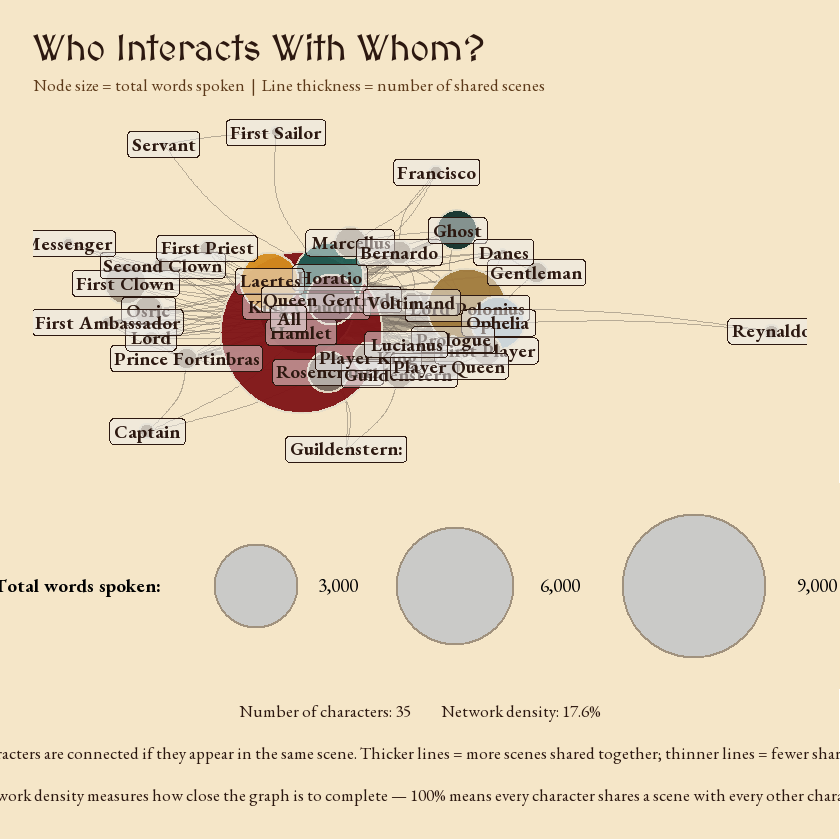

In [820]:
# ── 20c. Build tidygraph network and plot ──────────────────────────────────
network_graph <- as_tbl_graph(transitions_sym) %>%
  activate(nodes) %>%
  left_join(char_word_totals, by = c("name" = "character")) %>%
  mutate(node_color = ifelse(name %in% names(character_colors),
                             character_colors[name],
                             "#9c8e7a"))

# ── Network metrics ─────────────────────────────────────────────────────────
ig          <- igraph::as.igraph(network_graph)
n_chars     <- igraph::vcount(ig)
net_density <- round(igraph::edge_density(ig) * 100, 1)

set.seed(42)
network_layout <- create_layout(network_graph, layout = "igraph", algorithm = "fr")

network_plot <- ggraph(network_layout) +
  geom_edge_arc(
    aes(edge_width = n),
    edge_colour = "#7a7065",
    alpha       = 0.5,
    strength    = 0.1,
    show.legend = FALSE
  ) +
  geom_node_point(
    aes(size = words, fill = node_color),
    shape  = 21,
    colour = "#e6dec9",
    stroke = 1.2,
    alpha  = 0.95
  ) +
  scale_fill_identity() +
  geom_node_label(
    aes(label = name),
    colour        = "#2C1810",
    fill          = alpha("grey92", 0.5),
    label.size    = 0.15,
    family        = "Garamond",
    fontface      = "bold",
    size          = 5.0,
    label.padding = unit(0.20, "lines")
  ) +
  scale_edge_width(range = c(0.4, 8), guide = "none") +
  scale_size_area(
    max_size = 45,
    labels   = scales::comma,
    name     = "Total words spoken:"
  ) +
  guides(
    size = guide_legend(
      override.aes = list(fill = "#c8c8c8", colour = "#9c8e7a")
    )
  ) +
  labs(
    title    = "Who Interacts With Whom?",
    subtitle = "Node size = total words spoken  |  Line thickness = number of shared scenes",
    caption  = paste0(
      "Number of characters: ", n_chars,
      "          Network density: ", net_density, "%\n",
      "Two characters are connected if they appear in the same scene. ",
      "Thicker lines = more scenes shared together; thinner lines = fewer shared scenes.\n",
      "Network density measures how close the graph is to complete — ",
      "100% means every character shares a scene with every other character."
    )
  ) +
  theme(
    panel.background  = element_rect(fill = "#F5E6C8", color = NA),
    plot.background   = element_rect(fill = "#F5E6C8", color = NA),
    legend.background = element_rect(fill = "#F5E6C8", color = NA),
    legend.key        = element_rect(fill = "#F5E6C8", color = NA),
    plot.title    = element_text(size = 28, face = "bold",
                                 family = "MedievalSharp", color = "#2C1810",
                                 margin = margin(b = 6)),
    plot.subtitle = element_text(size = 13, family = "Garamond",
                                 color = "#5D3A1A", margin = margin(b = 12)),
    plot.caption  = element_text(family = "Garamond", size = 13,
                                 color = "#2C1810", hjust = 0.5,
                                 lineheight = 1.6, margin = margin(t = 10)),
    legend.text   = element_text(family = "Garamond", size = 14),
    legend.title  = element_text(family = "Garamond", size = 14, face = "bold"),
    legend.position = "bottom",
    plot.margin     = margin(20, 20, 20, 20)
  )

print(network_plot)

## 21. Distinctive Words per Character (TF-IDF Style)

It's interesting to ask: what does each character talk about that is *unique* to them? The plot below shows the **most distinctive word stems** spoken by each of the top 20 characters.

Distinctiveness is computed as a simple **TF-IDF ratio**:

$$\text{relative} = \frac{\text{proportion of this word in character's speech}}{\text{proportion of this word across the full play}}$$

A high ratio means the character uses this word far more than the average — their verbal fingerprint. Words appearing fewer than 3 times are excluded to avoid noise.

> **Examples**: Polonius's top word is *daughter* — reflecting his obsession with Ophelia. The Ghost speaks of *blood*, *foul*, and *beneath*. Hamlet's distinctive words are surprisingly mundane, which reflects how his dialogue spans every topic in the play.

In [821]:
# ── 21b. Compute distinctive word stems (TF-IDF ratio) ─────────────────────
# Uses main_characters (top 8 by line count) — same set as all other plots
distinctive_words <- hamlet %>%
  filter(character != "[stage direction]",
         character %in% main_characters) %>%
  unnest_tokens(word, dialogue) %>%
  anti_join(stop_words, by = "word") %>%
  mutate(word_stem = wordStem(word, language = "english")) %>%
  count(word_stem, character) %>%
  group_by(character) %>%
  mutate(prop_this_character = n / sum(n)) %>%
  ungroup() %>%
  mutate(
    prop_overall = n / sum(n),
    relative     = prop_this_character / prop_overall
  ) %>%
  filter(n > 2) %>%
  group_by(character) %>%
  arrange(desc(relative), desc(n)) %>%
  slice(1:5) %>%
  ungroup()

distinctive_words <- distinctive_words %>%
  mutate(character = factor(character, levels = rev(main_characters)))

print(head(distinctive_words, 10))

# A tibble: 10 × 6
   word_stem character     n prop_this_character prop_overall relative
   <chr>     <fct>     <int>               <dbl>        <dbl>    <dbl>
 1 thou      Ghost         8             0.0252      0.000885    28.4 
 2 beneath   Ghost         4             0.0126      0.000442    28.4 
 3 blood     Ghost         4             0.0126      0.000442    28.4 
 4 foul      Ghost         4             0.0126      0.000442    28.4 
 5 hamlet    Ghost         4             0.0126      0.000442    28.4 
 6 thou      Hamlet       44             0.0104      0.00487      2.15
 7 sir       Hamlet       43             0.0102      0.00475      2.15
 8 king      Hamlet       35             0.00831     0.00387      2.15
 9 mother    Hamlet       33             0.00783     0.00365      2.15
10 play      Hamlet       29             0.00689     0.00321      2.15


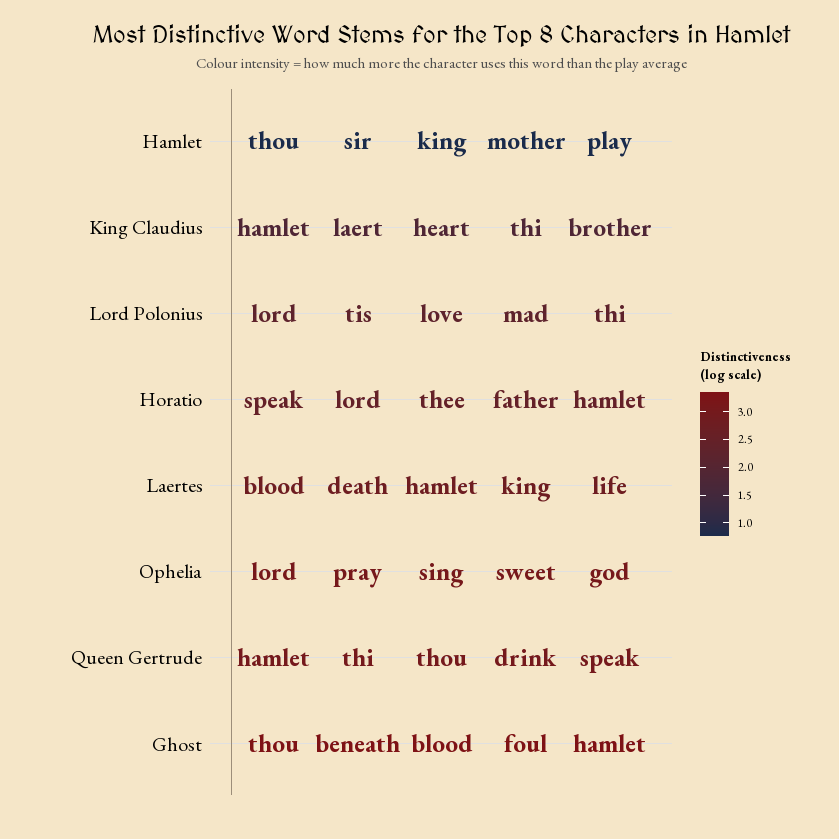

In [822]:
# ── 21c. Plot distinctive word stems ───────────────────────────────────────
distinctive_plot_data <- distinctive_words %>%
  group_by(character) %>%
  mutate(rank = row_number()) %>%
  ungroup()

distinctive_plot <- ggplot(
  distinctive_plot_data,
  aes(x = rank, y = character, label = word_stem, colour = log(relative))
) +
  geom_text(size = 6.5, family = "Garamond", fontface = "bold") +
  geom_vline(xintercept = 0.5, colour = "#9c8e7a", linewidth = 0.4) +
  scale_colour_gradient(
    low  = "#1a2b4b",
    high = "#7e1215",
    name = "Distinctiveness\n(log scale)"
  ) +
  scale_x_continuous(limits = c(0.5, 5.5), breaks = 1:5) +
  labs(
    title    = "Most Distinctive Word Stems for the Top 8 Characters in Hamlet",
    subtitle = "Colour intensity = how much more the character uses this word than the play average",
    x = "",
    y = ""
  ) +
  theme_minimal(base_family = "Garamond") +
  theme(
    axis.text.x        = element_blank(),
    axis.ticks.x       = element_blank(),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    panel.grid.major.y = element_line(colour = "grey88", linewidth = 0.3),
    plot.background    = element_rect(fill = "#F5E6C8", color = NA),
    panel.background   = element_rect(fill = "#F5E6C8", color = NA),
    legend.background  = element_rect(fill = "#F5E6C8", color = NA),
    legend.key         = element_rect(fill = "#F5E6C8", color = NA),
    plot.title    = element_text(size = 18, face = "bold",
                                 family = "MedievalSharp", hjust = 0.5,
                                 margin = margin(b = 6)),
    plot.subtitle = element_text(size = 11, family = "Garamond",
                                 hjust = 0.5, colour = "grey30",
                                 margin = margin(b = 10)),
    axis.text.y   = element_text(size = 15, family = "Garamond",
                                 hjust = 1, colour = "black"),
    legend.title  = element_text(size = 10, family = "Garamond", face = "bold"),
    legend.text   = element_text(size = 9,  family = "Garamond"),
    legend.position = "right",
    plot.margin   = margin(15, 15, 15, 15)
  )

print(distinctive_plot)

## 23. Scene Presence Heatmap

Each cell shows how many lines a character speaks in a given scene. Blank (bone white) means the character is absent entirely. Colour intensity runs from pale to deep crimson — the darker the cell, the more dominant the character is in that scene.

Act boundaries are marked with vertical lines. This makes structural absences immediately visible — most notably Hamlet's near-disappearance in Act IV when he is sent to England.

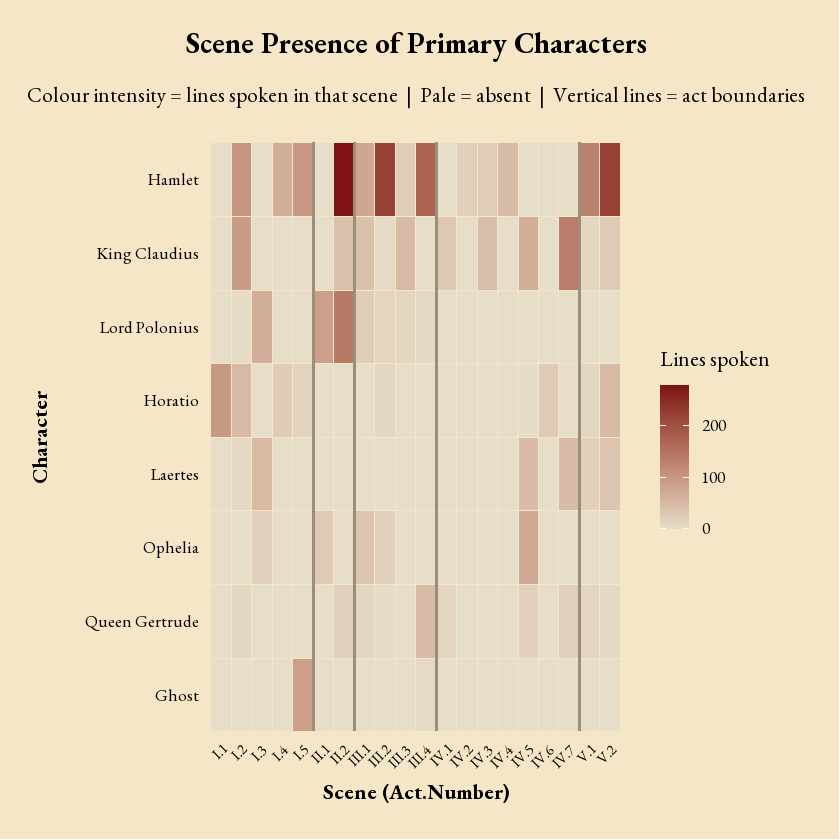

In [823]:
# ── 23a. Build scene presence data ─────────────────────────────────────────
act_labels <- c("Act I" = "I", "Act II" = "II", "Act III" = "III",
                "Act IV" = "IV", "Act V" = "V")

scene_presence <- hamlet %>%
  filter(character %in% main_characters) %>%
  group_by(character, act, scene) %>%
  summarise(lines = n(), .groups = "drop") %>%
  mutate(
    act_num  = match(act, names(act_labels)),
    # Robustly convert scene to integer: try direct int → Roman numeral →
    # extract trailing Roman numeral from strings like "Scene IV"
    scene_num = {
      s <- as.character(scene)
      coalesce(
        suppressWarnings(as.integer(s)),
        suppressWarnings(as.integer(as.roman(s))),
        suppressWarnings(as.integer(as.roman(
          gsub("^.*\\s([IVXivx]+)$", "\\1", trimws(s))
        )))
      )
    },
    # Clean label: "I.1", "I.2", "II.1" …
    scene_label = paste0(act_labels[act], ".", scene_num)
  )

# Ordered scene labels — sort by act then integer scene number
scene_order <- scene_presence %>%
  distinct(act_num, scene_num, scene_label) %>%
  arrange(act_num, scene_num) %>%
  pull(scene_label)

# Act separator x-positions
act_sep <- scene_presence %>%
  distinct(act_num, scene_label) %>%
  group_by(act_num) %>%
  summarise(n_scenes = n(), .groups = "drop") %>%
  arrange(act_num) %>%
  mutate(xpos = cumsum(n_scenes) + 0.5) %>%
  filter(act_num < 5)

# Complete grid: zero lines for absent characters
scene_heatmap_data <- scene_presence %>%
  complete(character, scene_label = scene_order, fill = list(lines = 0)) %>%
  mutate(
    scene_label = factor(scene_label, levels = scene_order),
    character   = factor(character, levels = levels(character_totals$character))
  )

# ── 23b. Plot heatmap ───────────────────────────────────────────────────────
heatmap_plot <- ggplot(scene_heatmap_data,
                       aes(x = scene_label, y = character, fill = lines)) +
  geom_tile(color = "#F5E6C8", linewidth = 0.4) +
  geom_vline(
    data        = act_sep,
    aes(xintercept = xpos),
    color       = "#9c8e7a",
    linewidth   = 1.0,
    inherit.aes = FALSE
  ) +
  scale_fill_gradient(
    low      = "#e6dec9",
    high     = "#7e1215",
    name     = "Lines spoken",
    na.value = "#e6dec9"
  ) +
  scale_x_discrete(expand = c(0, 0)) +
  scale_y_discrete(expand = c(0, 0)) +
  labs(
    title    = "Scene Presence of Primary Characters",
    subtitle = "Colour intensity = lines spoken in that scene  |  Pale = absent  |  Vertical lines = act boundaries",
    x        = "Scene (Act.Number)",
    y        = "Character"
  ) +
  hamlet_theme() +
  theme(
    axis.text.x     = element_text(angle = 45, hjust = 1, size = 11, family = "Garamond"),
    axis.text.y     = element_text(size = 13, family = "Garamond"),
    axis.title      = element_text(size = 16, face = "bold", family = "Garamond"),
    panel.grid      = element_blank(),
    legend.position = "right",
    plot.title      = element_text(hjust = 0.5, family = "Garamond", size = 22)
  )

print(heatmap_plot)

In [ ]:
# ── Assemble Vertical Narrative Poster ──────────────────────────────────────

make_header <- function(number, question) {
  ggplot() +
    annotate("text",
             x = 0.03, y = 0.72, label = paste0(number, "  ·  ", question),
             hjust = 0, vjust = 0.5, size = 11,
             family = "MedievalSharp", color = "#2C1810", fontface = "bold") +
    annotate("segment",
             x = 0.02, xend = 0.98, y = 0.15, yend = 0.15,
             color = "#a07a3c", linewidth = 1.0) +
    xlim(0, 1) + ylim(0, 1) +
    theme_void() +
    theme(plot.background = element_rect(fill = "#F5E6C8", color = NA),
          plot.margin     = margin(20, 30, 5, 30))
}

# ── 1. Title ─────────────────────────────────────────────────────────────────
title_panel <- ggplot() +
  annotate("text", x = 0.5, y = 0.5,
           label = "A Visual Analysis of Hamlet by Shakespeare",
           hjust = 0.5, vjust = 0.5, size = 20,
           family = "UnifrakturMaguntia", color = "#2C1810") +
  xlim(0, 1) + ylim(0, 1) +
  theme_void() +
  theme(plot.background = element_rect(fill = "#F5E6C8", color = NA),
        plot.margin     = margin(30, 30, 10, 30))

# ── 2. Intro text ────────────────────────────────────────────────────────────
intro_panel <- ggplot() +
  annotate("text", x = 0.5, y = 0.5,
           label = paste0(
             "Shakespeare's longest play, Hamlet is a revenge tragedy following a Danish prince who\n",
             "discovers his father was murdered by his uncle — now king and husband to his mother.\n\n",
             "To tell this story through data, we explore four questions: who dominates the stage,\n",
             "when each character appears, how the mood shifts across the play, and what words\n",
             "define each character's voice.\n\n",
             "Never read Hamlet? Think of it as The Lion King — but darker.\n",
             "The table below maps each character to their Disney counterpart."
           ),
           hjust = 0.5, vjust = 0.5, size = 7, family = "Garamond",
           color = "#3E2723", lineheight = 1.8) +
  xlim(0, 1) + ylim(0, 1) +
  theme_void() +
  theme(plot.background = element_rect(fill = "#F5E6C8", color = NA),
        plot.margin     = margin(5, 30, 5, 30))

# ── 3. Lion King comparison table ────────────────────────────────────────────
lk_data <- data.frame(
  `Hamlet`     = c("Hamlet", "King Claudius", "Ghost (King Hamlet)", "Queen Gertrude",
                   "Ophelia", "Horatio", "Lord Polonius", "Laertes"),
  `Lion King`  = c("Simba", "Scar", "Mufasa", "Sarabi",
                   "Nala", "Timon & Pumbaa", "Zazu", "Rafiki"),
  `Role`       = c("The prince haunted by his father's murder",
                   "The villainous uncle who seized the throne",
                   "The murdered king who returns as a ghost",
                   "The queen caught between past and present",
                   "The love interest undone by grief",
                   "The loyal friend who keeps the hero grounded",
                   "The meddling adviser obsessed with control",
                   "Confronts the protagonist and pushes him toward action"),
  check.names  = FALSE
)

lk_theme <- ttheme_minimal(
  base_family = "Garamond",
  base_size   = 13,
  core = list(
    fg_params = list(col = "#2C1810", fontfamily = "Garamond", fontsize = 13,
                     x = 0.06, hjust = 0),
    bg_params = list(fill = c("#F5E6C8", "#ede0c4"), col = "#a07a3c", lwd = 0.6)
  ),
  colhead = list(
    fg_params = list(col = "#2C1810", fontfamily = "Garamond",
                     fontsize = 14, fontface = "bold",
                     x = 0.06, hjust = 0),
    bg_params = list(fill = "#d4b896", col = "#a07a3c", lwd = 0.8)
  )
)

lk_grob  <- tableGrob(lk_data, rows = NULL, theme = lk_theme)
lk_panel <- wrap_elements(full = lk_grob) +
  theme(plot.background = element_rect(fill = "#F5E6C8", color = NA),
        plot.margin     = margin(5, 20, 20, 20))

# ── Caption panel ────────────────────────────────────────────────────────────
caption_panel <- ggplot() +
  annotate("text", x = 0.5, y = 0.5,
           label = "Andrés Ramírez Arroyo  •  Ferdinand Rasmussen  •  Federica Selvini  •  Max Voss  •  Jad Zoghaib",
           hjust = 0.5, size = 5.5, family = "Garamond", color = "#3E2723") +
  xlim(0, 1) + ylim(0, 1) +
  theme_void() +
  theme(plot.background = element_rect(fill = "#F5E6C8", color = NA),
        plot.margin     = margin(10, 30, 20, 30))

h1 <- make_header("01", "Who is in this play — and who dominates the stage?")
h2 <- make_header("02", "When do the characters appear?")
h3 <- make_header("03", "How does the mood evolve?")
h4 <- make_header("04", "What defines each character's voice?")

complete_poster <-
  title_panel /
  intro_panel /
  lk_panel /
  h1 / network_plot /
  h2 / heatmap_plot /
  h3 / line_sentiment_plot /
  h4 / distinctive_plot /
  caption_panel +
  plot_layout(heights = c(
    2.5,       # title
    9.0,       # intro text
    5.0,       # Lion King table
    1.2, 16,   # 01 + network
    1.2, 7,    # 02 + heatmap
    1.2, 9,    # 03 + sentiment
    1.2, 7,    # 04 + distinctive words
    1.2        # caption
  )) &
  theme(plot.background = element_rect(fill = "#F5E6C8", color = NA))

print(complete_poster)

ggsave(
  "hamlet_analysis_visualization.pdf",
  complete_poster,
  width     = 22,
  height    = 67,
  limitsize = FALSE,
  bg        = "#F5E6C8"
)